# Exponentiell viele Simplexiterationen sind extrem selten

* Für alle gängigen Pivotregeln sind Beispiele von linearen Programmen bekannt mit $O(n)$ Variablen und Ungleichungen, für die der Simplexalgorithmus exponentiell viele Iterationen benötigt, also $\Omega(2^n)$ viele. (Siehe Klee und Minty 1972.)
* In der Praxis wird dies nicht beobachtet: Ein lineares Programm mit $n$ Variablen und $m$ Ungleichungen terminiert gewöhnlich nach $O(m^2+n^2)$ Iterationen und oft deutlich schneller.
* [Spielmann und Teng](https://arxiv.org/abs/cs/0111050) (2001) bieten eine Erklärung für diesen Widerspruch zwischen *worst-case* Analyse und praktischer Erfahrung: Die linearen Programme, die exponentiell viele Simplexiterationen erzwingen, sind extrem sensitiv gegenüber Störungen; kleine Änderungen der Parameter führen bereits zu deutlich weniger Simplexiterationen.
* In diesem Notebook werden wir das Klee und Minty-Beispiel aufgreifen, leicht stören und beobachten wie sich die Zahl der Simplexiterationen verhält.

Als erstes machen wir ein paar nötige imports und laden Visualisierungscode und eine Version des Simplexalgorithmus.

In [3]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

rng=np.random.default_rng()

# Nur, wenn Sie in Colab arbeiten
!wget -q https://raw.githubusercontent.com/henningbruhn/opt1/main/polyview.py
!wget -q https://raw.githubusercontent.com/henningbruhn/opt1/main/simplex.py

from polyview import setup_simplex_widget
import simplex

Wir laden die Klee und Minty-Instanz und beobachten, dass tatsächlich der Simplexalgorithmus alle $2^3$ Ecken besucht.

In [2]:
setup_simplex_widget(*simplex.twisted_cube())

OPT found
 at x=[  0.  -0. 125.]
 OPT value=125.0
simplex took 8 steps


Nun stören wir das Klee und Minty-Beispiel und beobachten, wie viele Iterationen benötigt werden.

In [6]:
def perturb(A,b,c=None,scale=1):
  """Wir addieren auf alle Parameter jeweils normalverteilte Störungen."""
  A=np.asarray(A)
  b=np.asarray(b)
  A=A+rng.normal(size=A.shape,scale=scale)
  b=b+rng.normal(size=b.shape,scale=scale)
  if c is not None:
    c=np.asarray(c)
    c=c+rng.normal(size=c.shape,scale=scale)
    return A,b,c
  return A,b

def get_start_vx(A,b):
  """Die kanonische Startecke funktioniert nicht mehr im gestörten System.
  Daher benutzen wir die (professionelle) Implementation des Simplex in scipy, um uns eine Startecke zu beschaffen."""
  res=sp.optimize.linprog(np.ones(A.shape[1]),A_ub=A,b_ub=b,bounds=(-np.inf,np.inf))
  return res.x

A,b,c,x0 = simplex.twisted_cube()

# wir stören A,b,c leicht
A_noisy,b_noisy,c_noisy=perturb(A,b,c,scale=0.1)
# wir beschaffen uns eine Startecke in der Nähe des Ursprungs
x0=get_start_vx(A_noisy,b_noisy)
assert x0 is not None # wenn wir Pech haben, ist das LP unzulässig

setup_simplex_widget(A_noisy,b_noisy,c_noisy,x0)

LP unbounded
simplex took 7 steps


Sie sollten weniger Iterationen beobachten. Da die Störungen jedoch zufällig sind, schwankt die Zahl. Wir machen daher noch eine systematische Untersuchung in höheren Dimensionen, etwa im $\mathbb R^{2^n}$ für $n=7$ oder $n=8$. Um uns weniger abhängig von den zufälligen Störungen zu machen, wiederholen wir den Versuch viele mal (1000$\times$ oder mehr, je nachdem wie viel Geduld Sie aufbringen).

Um den Code recyclen zu können, übergeben wir die Methode <code>inst_fun</code> zur Instanzerzeugung als Parameter. Die LP-Dimension <code>n</code> und die Größe der Störung <code>scale</code> sind ebenfalls Parameter. Schließlich steuert <code>repeats</code> wie oft alles wiederholt wird.

In [26]:
def run_perturbed_simplex(inst_fun,n,scale,repeats=1000,example=False):
  results=[]
  for _ in range(repeats):
    A,b,c,x0 = inst_fun(n=n)
    A_noisy,b_noisy,c_noisy=perturb(A,b,c,scale=scale)
    res=sp.optimize.linprog(np.ones(A_noisy.shape[1]),A_ub=A_noisy,b_ub=b_noisy,bounds=(-np.inf,np.inf))
    if res.x is None: # no solution found
      results.append((None,"infeasible",None))
      continue
    x0=res.x
    S=simplex.Simplex(A_noisy,b_noisy,c_noisy,x0,verbose=False)
    steps=len(S.record)-1 # first entry is starting vx, not a step
    opt_found=S.opt_status=="OPT found"
    opt_val = S.current_objective() if opt_found else np.inf
    results.append((steps,S.opt_status,opt_val))

  if example:
    print("example")
    print("b original : "+", ".join([f"{s: .3f}" for s in np.round(b.reshape(-1),3)]))
    print("b perturbed: "+", ".join([f"{s: .3f}" for s in np.round(b_noisy.reshape(-1),3)]))
  return results

n=7
scale=0.01
repeats=1000
results=run_perturbed_simplex(simplex.twisted_cube,n,scale,repeats=repeats,example=True)

example
b original:  0.003,  4.999,  0.002,  24.999, -0.009,  124.993, -0.006,  625.002,  0.001,  3125.010, -0.005,  15625.000,  0.009,  78124.986
b pertubed:  0.000,  5.000,  0.000,  25.000,  0.000,  125.000,  0.000,  625.000,  0.000,  3125.000,  0.000,  15625.000,  0.000,  78125.000


Bevor wir die Resultate auswerten: Der Vergleich der ursprünglichen rechten Seite $b$ des linearen Programms mit der gestörten rechten Seite, zeigt wie gering die Störungen sind. Man sollte erwarten, dass die Störungen kaum Auswirkungen zeigen. Dass die Auswirkungen jedoch substantiell sind, zeigt folgende Graphik, in der ein Histogramm der Simplexiterationen geplottet ist.

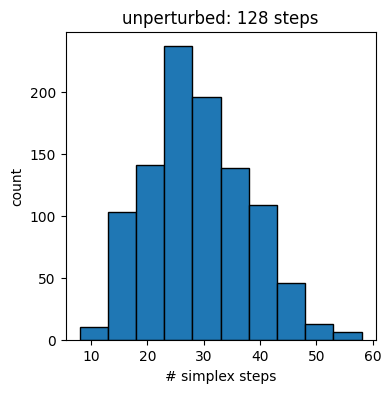

In [27]:
feasible_steps=[steps for steps,opt_found,val in results if opt_found!="infeasible"]
fig,ax=plt.subplots(figsize=(4,4))


ax.hist(feasible_steps,edgecolor="black")
ax.set_xlabel("# simplex steps")
ax.set_ylabel("count")
ax.set_title(f"unperturbed: {2**n} steps")
pass

Statt 128 Schritten (bei $n=7$) braucht es nun weniger als 60 und oft unter 30. Dies ist eine beachtliche Reduktion. Wir können ebenfalls beobachten (in der nächsten Zelle), dass das lineare Programm sogar unbeschränkt werden kann -- obwohl die Störungen gering sind.

In [12]:
from collections import Counter
outcomes = [outcome for _,outcome,_ in results]
count = Counter(outcomes)
count

Counter({'OPT found': 931, 'unbounded': 69})

Als quasi Gegenprobe wenden wir das gleiche Verfahren auf ein sehr harmloses lineares Programm an: Wir maximieren den Einsvektor über einem Hyperwürfel, wobei wir bei $0$ starten. Dazu basteln wir uns zunächst eine Methode, die die Instanz erzeugt. Wir visualisieren den Fall $n=3$.

In [16]:
def gen_hypercube(n):
  A=np.vstack([np.eye(n),-np.eye(n)])
  b=np.array([1]*n+[0]*n)
  return A,b

def hypercube_inst(n):
  A,b=gen_hypercube(n)
  c=np.ones(n)
  x0=np.zeros(n)
  return A,b,c,x0

setup_simplex_widget(*hypercube_inst(3))

OPT found
 at x=[1. 1. 1.]
 OPT value=3.0
simplex took 4 steps


Für den Hyperwürfel im $\mathbb R^n$ sind $n$ Simplexiterationen nötig. Wir werden sehen, dass sich daran auch unter Störungen nichts ändert.

In [25]:
n=20
scale=0.01
repeats=1000
results=run_perturbed_simplex(hypercube_inst,n,scale,repeats=repeats)

feasible_steps=[steps for steps,opt_found,val in results if opt_found!="infeasible"]

step_counter = Counter(feasible_steps)
step_counter

Counter({20: 1000})